# BTC TRAMA Research

This notebook studies a TRAMA-based intraday trading strategy on BTC data.

Main focus:
- signal logic
- backtest behavior
- parameter sensitivity
- Monte Carlo robustness

In [1]:
# Если нужно (в Colab/новом окружении):
# !pip -q install yfinance pandas numpy matplotlib

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


In [2]:
SYMBOL = "BTC-USD"
INTERVAL = "5m"
PERIOD = "60d"   # у Yahoo 5m ограничение по истории, чаще всего 30-60 дней

df = yf.download(SYMBOL, interval=INTERVAL, period=PERIOD, auto_adjust=False, progress=False)

# стандартизируем колонки
df = df.rename(columns=str.lower)
df = df.rename(columns={"adj close": "adj_close"})
df = df.dropna()
df.index = pd.to_datetime(df.index)

df.head(), df.tail(), df.shape


(Price                         adj_close         close          high  \
 Ticker                          btc-usd       btc-usd       btc-usd   
 Datetime                                                              
 2025-12-22 00:00:00+00:00  88683.218750  88683.218750  88729.109375   
 2025-12-22 00:05:00+00:00  88872.726562  88872.726562  88872.726562   
 2025-12-22 00:10:00+00:00  89295.578125  89295.578125  89295.578125   
 2025-12-22 00:15:00+00:00  89160.218750  89160.218750  89577.710938   
 2025-12-22 00:20:00+00:00  89007.250000  89007.250000  89155.859375   
 
 Price                               low          open     volume  
 Ticker                          btc-usd       btc-usd    btc-usd  
 Datetime                                                          
 2025-12-22 00:00:00+00:00  88621.664062  88621.664062          0  
 2025-12-22 00:05:00+00:00  88727.343750  88727.343750          0  
 2025-12-22 00:10:00+00:00  88898.148438  88898.148438  300800000  
 2025-12-22 00

In [6]:
# --- FIX: привести данные Yahoo к обычным 1-уровневым колонкам ---

# 1) если колонки MultiIndex -> сплющить
if isinstance(df.columns, pd.MultiIndex):
    # берём первый уровень (обычно это OHLCV)
    df.columns = [c[0] for c in df.columns]

# 2) привести имена к lower и стандартизировать
df = df.rename(columns=str.lower).rename(columns={"adj close": "adj_close"})

# 3) оставить только нужное + убедиться что это Series-колонки
need = ["open","high","low","close","volume"]
df = df[[c for c in need if c in df.columns]].copy()

# 4) числа -> float, NaN убрать
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna()

df.head(), df.columns, df.dtypes


(                                   open          high           low  \
 Datetime                                                              
 2025-12-22 00:00:00+00:00  88621.664062  88729.109375  88621.664062   
 2025-12-22 00:05:00+00:00  88727.343750  88872.726562  88727.343750   
 2025-12-22 00:10:00+00:00  88898.148438  89295.578125  88898.148438   
 2025-12-22 00:15:00+00:00  89396.585938  89577.710938  89160.218750   
 2025-12-22 00:20:00+00:00  89155.859375  89155.859375  88930.679688   
 
                                   close     volume  
 Datetime                                            
 2025-12-22 00:00:00+00:00  88683.218750          0  
 2025-12-22 00:05:00+00:00  88872.726562          0  
 2025-12-22 00:10:00+00:00  89295.578125  300800000  
 2025-12-22 00:15:00+00:00  89160.218750  463902720  
 2025-12-22 00:20:00+00:00  89007.250000  172564480  ,
 Index(['open', 'high', 'low', 'close', 'volume'], dtype='object'),
 open      float64
 high      float64
 low     

In [23]:
def true_range(high, low, close):
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr

def atr(high, low, close, length=14):
    tr = true_range(high, low, close)
    return tr.ewm(alpha=1/length, adjust=False).mean()

def trama(src_close, high, low, length=20):
    hh = np.sign(high.rolling(length).max().diff()).clip(lower=0)
    ll = (np.sign(low.rolling(length).min().diff()) * -1).clip(lower=0)
    cond = ((hh != 0) | (ll != 0)).astype(float)

    tc = (cond.rolling(length, min_periods=1).mean() ** 2).fillna(0.0)

    ama = pd.Series(index=src_close.index, dtype=float)
    ama.iloc[0] = float(src_close.iloc[0])

    for i in range(1, len(src_close)):
        prev = ama.iloc[i-1]
        a = float(tc.iloc[i])
        ama.iloc[i] = prev + a * (float(src_close.iloc[i]) - prev)

    return ama


def resample_ohlc(df_5m, tf="60min"):
    """
    Yahoo 5m -> 60m OHLC
    """
    o = df_5m["open"].resample(tf).first()
    h = df_5m["high"].resample(tf).max()
    l = df_5m["low"].resample(tf).min()
    c = df_5m["close"].resample(tf).last()
    out = pd.concat([o,h,l,c], axis=1)
    out.columns = ["open","high","low","close"]
    return out.dropna()


In [32]:
df60.head(5)


,open,high,low,close,trama_slow_60
Datetime,,,,,
2025-12-22 00:00:00+00:00,88621.664062,89577.710938,88621.664062,88837.757812,88837.757812
2025-12-22 01:00:00+00:00,88639.453125,89220.968750,88564.359375,88641.953125,88641.953125
2025-12-22 02:00:00+00:00,88641.812500,88641.812500,88013.031250,88443.007812,88443.007812
2025-12-22 03:00:00+00:00,88433.671875,88775.640625,88321.382812,88758.171875,88758.171875
2025-12-22 04:00:00+00:00,88783.273438,88986.210938,88702.585938,88907.117188,88907.117188


In [93]:
# параметры как в Pine
lenFast = 50
lenSlow = 40

atrLen = 20
minDistATR = 3.2

tpQtyPct = 60

trailATR_CT = 1.2
trailATR_TR = 4.4

# 5m индикаторы
df["atr"] = atr(df["high"], df["low"], df["close"], atrLen)
df["trama_fast"] = trama(df["close"], df["high"], df["low"], lenFast)

# 60m -> slow TRAMA -> на 5m
df60 = resample_ohlc(df, "60min")
df60["trama_slow_60"] = trama(df60["close"], df60["high"], df60["low"], lenSlow)

# протягиваем slow на 5m бары
df["trama_slow"] = df60["trama_slow_60"].reindex(df.index, method="ffill")

df[["close","trama_fast","trama_slow","atr"]].dropna().head()


,close,trama_fast,trama_slow,atr
Datetime,,,,
2025-12-22 00:00:00+00:00,88683.218750,88683.218750,88837.757812,107.445312
2025-12-22 00:05:00+00:00,88872.726562,88872.726562,88837.757812,111.548437
2025-12-22 00:10:00+00:00,89295.578125,89295.578125,88837.757812,127.113594
2025-12-22 00:15:00+00:00,89160.218750,89160.218750,88837.757812,141.632523
2025-12-22 00:20:00+00:00,89007.250000,89007.250000,88837.757812,146.027850


In [94]:
# ===================== SIGNAL PREP (WITH VOLUME FILTER) =====================

x = df.copy()

# --- Volume filter ---
x["volUp"] = x["volume"].fillna(0) > x["volume"].shift(1).fillna(0)

# --- Crossover / Crossunder (close vs fast TRAMA) ---
prev_close = x["close"].shift(1)
prev_fast  = x["trama_fast"].shift(1)

x["crossUp"] = (
    (prev_close <= prev_fast) &
    (x["close"] > x["trama_fast"])
)

x["crossDown"] = (
    (prev_close >= prev_fast) &
    (x["close"] < x["trama_fast"])
)

# --- CT distance filter ---
x["distLong"]  = x["trama_slow"] - x["close"]
x["distShort"] = x["close"] - x["trama_slow"]

x["validDistLong"] = (
    x["distLong"] > x["atr"] * minDistATR
)

x["validDistShort"] = (
    x["distShort"] > x["atr"] * minDistATR
)

# --- защита от NaN в булевых колонках ---
bool_cols = [
    "crossUp", "crossDown",
    "validDistLong", "validDistShort",
    "volUp"
]

for col in bool_cols:
    x[col] = x[col].fillna(False)

df = x


In [115]:
# ===================== BACKTEST CELL (WITH VOLUME FILTER ON ALL ENTRIES) =====================
# + сохраняет историю трейлинга в df_bt["trail_stop"] и df_bt["trail_stop_side"]

import numpy as np
import pandas as pd
from dataclasses import dataclass

@dataclass
class Trade:
    entry_ts: pd.Timestamp
    side: str   # "long" or "short"
    entry_px: float
    mode: int   # 1/-1 CT, 2/-2 TR, 3/-3 FLIP
    exit_ts: pd.Timestamp | None = None
    exit_px: float | None = None
    reason: str | None = None

def run_backtest(df: pd.DataFrame):
    """
    pos: 0 flat, 1 long, -1 short
    posMode:
      1  CT long
     -1  CT short
      2  TR long
     -2  TR short
      3  FLIP short (после CT long fail/stop)
     -3  FLIP long  (после CT short fail/stop)

    Входы: ТОЛЬКО если volUp=True (volume[i] > volume[i-1]) для ВСЕХ входов: CT/TR/FLIP.
    Выходы: без volume фильтра (3-bar, trailing, partial TP).

    ВАЖНО: эта версия записывает историю трейлинга:
      - df["trail_stop"] (число)
      - df["trail_stop_side"] ('L'/'S'/nan)
    """

    # --- обязательные колонки ---
    need_cols = ["open","high","low","close","volume","atr","trama_fast","trama_slow",
                "crossUp","crossDown","validDistLong","validDistShort","volUp"]
    miss = [c for c in need_cols if c not in df.columns]
    if miss:
        raise ValueError(f"В df нет нужных колонок: {miss}. Сначала посчитай сигналы (включая volUp).")

    # --- подготовим колонки для истории стопов (будет рисоваться на графике) ---
    df = df.copy()
    df["trail_stop"] = np.nan
    df["trail_stop_side"] = np.nan  # 'L' / 'S'

    pos = 0
    posMode = 0

    qty = 1.0
    qty_open = 0.0

    ctNear = False
    ctNear_i = None

    # trend arm
    trArmL, trCntL = False, 0
    trArmS, trCntS = False, 0

    # trailing levels (текущие уровни в симуляторе)
    trailL = np.nan
    trailS = np.nan

    trades: list[Trade] = []
    cur_trade: Trade | None = None

    def _set_trail(i: int):
        """Записать текущий трейлинг (если есть) в df на баре i."""
        ts = df.index[i]
        if pos > 0 and not np.isnan(trailL):
            df.loc[ts, "trail_stop"] = float(trailL)
            df.loc[ts, "trail_stop_side"] = "L"
        elif pos < 0 and not np.isnan(trailS):
            df.loc[ts, "trail_stop"] = float(trailS)
            df.loc[ts, "trail_stop_side"] = "S"
        else:
            # оставляем NaN
            return

    def open_pos(i, side, mode):
        nonlocal pos, posMode, qty_open, ctNear, ctNear_i, trailL, trailS, cur_trade
        pos = 1 if side == "long" else -1
        posMode = int(mode)
        qty_open = qty
        ctNear = False
        ctNear_i = None
        trailL = np.nan
        trailS = np.nan
        cur_trade = Trade(entry_ts=df.index[i], side=side, entry_px=float(df["close"].iloc[i]), mode=int(mode))
        trades.append(cur_trade)
        _set_trail(i)  # на баре входа (пока NaN, но ок)

    def close_pos(i, px, reason):
        nonlocal pos, posMode, qty_open, ctNear, ctNear_i, trailL, trailS, cur_trade
        if pos == 0 or cur_trade is None:
            return
        cur_trade.exit_ts = df.index[i]
        cur_trade.exit_px = float(px)
        cur_trade.reason = reason
        pos = 0
        posMode = 0
        qty_open = 0.0
        ctNear = False
        ctNear_i = None
        trailL = np.nan
        trailS = np.nan
        cur_trade = None
        # на баре выхода оставляем уже записанное значение (если было)

    # --- основной цикл ---
    for i in range(2, len(df)):
        row = df.iloc[i]

        # пропуски (на старте или если slow ещё не готов)
        if np.isnan(row["trama_slow"]) or np.isnan(row["trama_fast"]) or np.isnan(row["atr"]):
            continue

        close = float(row["close"])
        high  = float(row["high"])
        low   = float(row["low"])
        slow  = float(row["trama_slow"])
        fast  = float(row["trama_fast"])
        atrv  = float(row["atr"])

        volUp = bool(row["volUp"])

        # ======================
        # 1) ЕСЛИ FLAT: TR setup + CT entries (входы только при volUp)
        # ======================
        if pos == 0:
            # --- TR LONG setup: пришли сверху + ретест (low<=slow) + 3 closes > slow ---
            if (df["close"].iloc[i-1] > df["trama_slow"].iloc[i-1]) and (low <= slow):
                trArmL = True
                trCntL = 0

            if trArmL:
                if close > slow:
                    trCntL += 1
                    if trCntL >= 3 and volUp:
                        open_pos(i, "long", mode=2)
                        trArmL, trCntL = False, 0
                else:
                    trArmL, trCntL = False, 0

            # --- TR SHORT setup: пришли снизу + ретест (high>=slow) + 3 closes < slow ---
            if (df["close"].iloc[i-1] < df["trama_slow"].iloc[i-1]) and (high >= slow):
                trArmS = True
                trCntS = 0

            if trArmS:
                if close < slow:
                    trCntS += 1
                    if trCntS >= 3 and volUp:
                        open_pos(i, "short", mode=-2)
                        trArmS, trCntS = False, 0
                else:
                    trArmS, trCntS = False, 0

            # --- CT entries (только если всё ещё flat) ---
            if pos == 0:
                ctLong  = volUp and (close < slow) and bool(row["crossUp"])   and bool(row["validDistLong"])
                ctShort = volUp and (close > slow) and bool(row["crossDown"]) and bool(row["validDistShort"])

                if ctLong:
                    open_pos(i, "long", mode=1)
                elif ctShort:
                    open_pos(i, "short", mode=-1)

            # если flat — стопов нет, нечего писать
            continue

        # ======================
        # 2) УПРАВЛЕНИЕ ОТКРЫТОЙ ПОЗИЦИЕЙ (выходы без vol фильтра)
        # ======================

        # trail multiplier: TR/Flip wider, CT narrower
        trail_mult = trailATR_TR if posMode in (2, -2, 3, -3) else trailATR_CT

        # ---- (A) CT partial TP at slow (intrabar touch) ----
        if posMode == 1:  # CT long
            if (not ctNear) and (high >= slow):
                ctNear = True
                ctNear_i = i

            if (high >= slow) and (qty_open > 0):
                qty_close = qty * (tpQtyPct / 100.0)
                if qty_open > (qty - qty_close) + 1e-9:
                    qty_open = qty_open - qty_close

        if posMode == -1:  # CT short
            if (not ctNear) and (low <= slow):
                ctNear = True
                ctNear_i = i

            if (low <= slow) and (qty_open > 0):
                qty_close = qty * (tpQtyPct / 100.0)
                if qty_open > (qty - qty_close) + 1e-9:
                    qty_open = qty_open - qty_close

        # ---- (B) CT 3-bar rule after near -> close remainder + flip (вход flip только если volUp) ----
        if posMode == 1 and ctNear and (ctNear_i is not None) and (i - ctNear_i >= 2):
            three_below = (df["close"].iloc[i]    < df["trama_slow"].iloc[i]) and \
                          (df["close"].iloc[i-1] < df["trama_slow"].iloc[i-1]) and \
                          (df["close"].iloc[i-2] < df["trama_slow"].iloc[i-2])
            if three_below:
                close_pos(i, close, "CT 3 closes below slow -> flip short")
                if (fast < slow) and volUp:
                    open_pos(i, "short", mode=3)
                continue

        if posMode == -1 and ctNear and (ctNear_i is not None) and (i - ctNear_i >= 2):
            three_above = (df["close"].iloc[i]    > df["trama_slow"].iloc[i]) and \
                          (df["close"].iloc[i-1] > df["trama_slow"].iloc[i-1]) and \
                          (df["close"].iloc[i-2] > df["trama_slow"].iloc[i-2])
            if three_above:
                close_pos(i, close, "CT 3 closes above slow -> flip long")
                if (fast > slow) and volUp:
                    open_pos(i, "long", mode=-3)
                continue

        # ---- (C) Update trailing stop level + записать его в df ----
        if pos > 0:  # long
            new_trail = close - atrv * trail_mult
            trailL = new_trail if np.isnan(trailL) else max(trailL, new_trail)
        else:        # short
            new_trail = close + atrv * trail_mult
            trailS = new_trail if np.isnan(trailS) else min(trailS, new_trail)

        _set_trail(i)  # <<< ВОТ ЗДЕСЬ мы записываем историю трейлинга для графика

        # ---- (D) Intrabar stop execution (выход без vol фильтра; вход flip только если volUp) ----
        if pos > 0 and not np.isnan(trailL) and (low <= trailL):
            was_ct = (posMode == 1)
            was_ct_near = ctNear
            close_pos(i, trailL, "Trailing stop hit (long)")
            if was_ct and was_ct_near and (fast < slow) and volUp:
                open_pos(i, "short", mode=3)
            continue

        if pos < 0 and not np.isnan(trailS) and (high >= trailS):
            was_ct = (posMode == -1)
            was_ct_near = ctNear
            close_pos(i, trailS, "Trailing stop hit (short)")
            if was_ct and was_ct_near and (fast > slow) and volUp:
                open_pos(i, "long", mode=-3)
            continue

        # Если partial TP закрыл всё (например tpQtyPct=100)
        if qty_open <= 1e-9:
            was_ct = (posMode in (1, -1))
            was_ct_near = ctNear
            side_now = "long" if pos > 0 else "short"
            close_pos(i, close, f"Position size reached 0 after partial (side={side_now})")
            if was_ct and was_ct_near and volUp:
                if side_now == "long" and (fast < slow):
                    open_pos(i, "short", mode=3)
                if side_now == "short" and (fast > slow):
                    open_pos(i, "long", mode=-3)
            continue

    # если в конце осталась позиция — закрываем по последнему close
    if pos != 0:
        close_pos(len(df)-1, float(df["close"].iloc[-1]), "End of data")

    # собрать трейды в df
    out = []
    for t in trades:
        if t.exit_ts is None:
            continue
        pnl = (t.exit_px - t.entry_px) if t.side == "long" else (t.entry_px - t.exit_px)
        out.append({
            "entry_ts": t.entry_ts, "exit_ts": t.exit_ts,
            "side": t.side, "mode": t.mode,
            "entry_px": t.entry_px, "exit_px": t.exit_px,
            "pnl_$": pnl,
            "reason": t.reason
        })
    trades_df = pd.DataFrame(out)

    return trades_df, df

# запуск
trades_df, df_bt = run_backtest(df.copy())
display(trades_df.head())
display(trades_df.tail())
print("trades_df shape:", trades_df.shape)
print("df_bt columns added:", [c for c in ["trail_stop","trail_stop_side"] if c in df_bt.columns])

/var/folders/3g/jmvmn_yx4vqdtkbl4gtw8b0w0000gn/T/ipykernel_3982/1689273185.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'L' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[ts, "trail_stop_side"] = "L"


,entry_ts,exit_ts,side,mode,entry_px,exit_px,pnl_$,reason
0,2025-12-22 00:40:00+00:00,2025-12-22 02:00:00+00:00,long,2,89061.546875,88557.809297,-503.737578,Trailing stop hit (long)
1,2025-12-22 14:40:00+00:00,2025-12-22 22:50:00+00:00,short,-2,89601.078125,88593.223105,1007.855020,Trailing stop hit (short)
2,2025-12-23 02:35:00+00:00,2025-12-23 03:10:00+00:00,short,-1,88472.101562,88001.113733,470.987830,Trailing stop hit (short)
3,2025-12-23 14:25:00+00:00,2025-12-23 14:35:00+00:00,short,-1,87600.640625,87466.350337,134.290288,Trailing stop hit (short)
4,2025-12-24 07:30:00+00:00,2025-12-24 10:10:00+00:00,short,-2,86935.765625,86960.640776,-24.875151,Trailing stop hit (short)


,entry_ts,exit_ts,side,mode,entry_px,exit_px,pnl_$,reason
171,2026-02-17 20:25:00+00:00,2026-02-17 21:00:00+00:00,long,1,67671.429688,67694.904765,23.475077,Trailing stop hit (long)
172,2026-02-19 01:20:00+00:00,2026-02-19 01:40:00+00:00,long,1,66621.664062,66674.070745,52.406683,Trailing stop hit (long)
173,2026-02-19 08:35:00+00:00,2026-02-19 09:05:00+00:00,long,1,66912.351562,66873.296811,-39.054752,Trailing stop hit (long)
174,2026-02-19 10:10:00+00:00,2026-02-19 10:30:00+00:00,long,1,66884.632812,66810.953710,-73.679103,Trailing stop hit (long)
175,2026-02-19 10:40:00+00:00,2026-02-19 10:50:00+00:00,long,1,66915.515625,66817.056209,-98.459416,Trailing stop hit (long)


trades_df shape: (176, 8)
df_bt columns added: ['trail_stop', 'trail_stop_side']


In [116]:
if trades_df.empty:
    print("Сделок нет — проверь период/параметры.")
else:
    print("Trades:", len(trades_df))
    print("Total PnL ($):", trades_df["pnl_$"].sum())
    print("Avg PnL ($):", trades_df["pnl_$"].mean())
    print("Win rate:", (trades_df["pnl_$"] > 0).mean())

trades_df.tail(10)


Trades: 176
Total PnL ($): -2611.25923833211
Avg PnL ($): -14.836700217796079
Win rate: 0.4034090909090909


,entry_ts,exit_ts,side,mode,entry_px,exit_px,pnl_$,reason
166,2026-02-15 10:55:00+00:00,2026-02-15 12:05:00+00:00,short,-1,70415.593750,70265.188857,150.404893,Trailing stop hit (short)
167,2026-02-16 00:30:00+00:00,2026-02-16 04:05:00+00:00,short,-2,68882.773438,68526.519768,356.253669,Trailing stop hit (short)
168,2026-02-16 12:20:00+00:00,2026-02-16 13:00:00+00:00,short,-2,68844.703125,69826.952705,-982.249580,Trailing stop hit (short)
169,2026-02-17 01:15:00+00:00,2026-02-17 02:00:00+00:00,long,2,68854.507812,68557.198953,-297.308859,Trailing stop hit (long)
170,2026-02-17 18:25:00+00:00,2026-02-17 19:15:00+00:00,long,1,67713.648438,67954.390871,240.742433,Trailing stop hit (long)
171,2026-02-17 20:25:00+00:00,2026-02-17 21:00:00+00:00,long,1,67671.429688,67694.904765,23.475077,Trailing stop hit (long)
172,2026-02-19 01:20:00+00:00,2026-02-19 01:40:00+00:00,long,1,66621.664062,66674.070745,52.406683,Trailing stop hit (long)
173,2026-02-19 08:35:00+00:00,2026-02-19 09:05:00+00:00,long,1,66912.351562,66873.296811,-39.054752,Trailing stop hit (long)
174,2026-02-19 10:10:00+00:00,2026-02-19 10:30:00+00:00,long,1,66884.632812,66810.953710,-73.679103,Trailing stop hit (long)
175,2026-02-19 10:40:00+00:00,2026-02-19 10:50:00+00:00,long,1,66915.515625,66817.056209,-98.459416,Trailing stop hit (long)


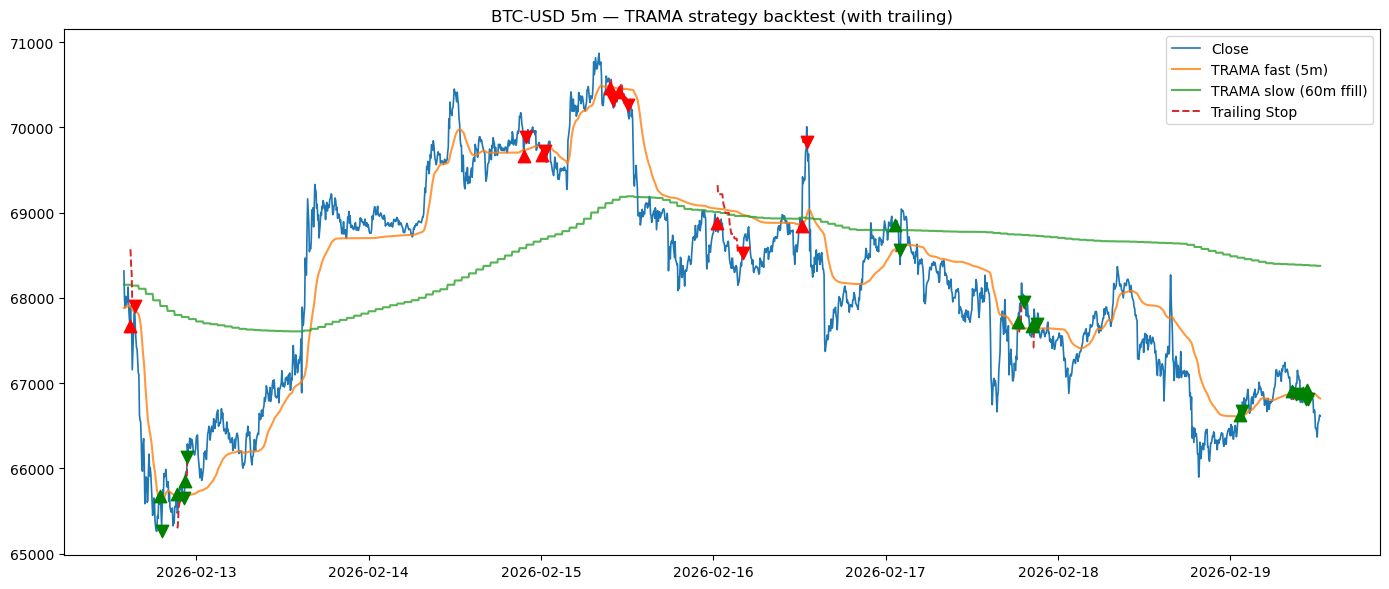

In [117]:
#plot_n = len(df_bt)
plot_n = 2000
d = df_bt.iloc[-plot_n:].copy()

plt.figure(figsize=(14,6))

# Цена и TRAMA
plt.plot(d.index, d["close"], label="Close", linewidth=1.2)
plt.plot(d.index, d["trama_fast"], label="TRAMA fast (5m)", alpha=0.8)
plt.plot(d.index, d["trama_slow"], label="TRAMA slow (60m ffill)", alpha=0.8)

# === ТРЕЙЛИНГ СТОП ===
# замените "trail_stop" на реальное имя колонки
if "trail_stop" in d.columns:
    plt.plot(d.index, d["trail_stop"],
             label="Trailing Stop",
             linestyle="--",
             linewidth=1.4)

# === Сделки ===
if not trades_df.empty:
    tsub = trades_df[
        trades_df["entry_ts"].between(d.index.min(), d.index.max())
    ]
    for _, r in tsub.iterrows():
        c = "green" if r["side"] == "long" else "red"
        plt.scatter(r["entry_ts"], r["entry_px"],
                    marker="^", color=c, s=80, zorder=5)
        plt.scatter(r["exit_ts"], r["exit_px"],
                    marker="v", color=c, s=80, zorder=5)

plt.legend()
plt.title(f"{SYMBOL} {INTERVAL} — TRAMA strategy backtest (with trailing)")
plt.tight_layout()
plt.show()

,Сделок,Win rate,Profit factor,Avg win ($),Avg loss ($),Expectancy ($/trade),Total return,CAGR (approx),Sharpe (5m),Sortino (5m),Max DD,Buy&Hold return,Buy&Hold CAGR,Buy&Hold Sharpe,Buy&Hold Max DD
0,176,0.403409,0.863193,232.055489,-181.782847,-14.8367,-0.012952,-0.076832,-0.331539,-0.148185,-0.093426,-0.248856,-0.82706,-3.036049,-0.380743


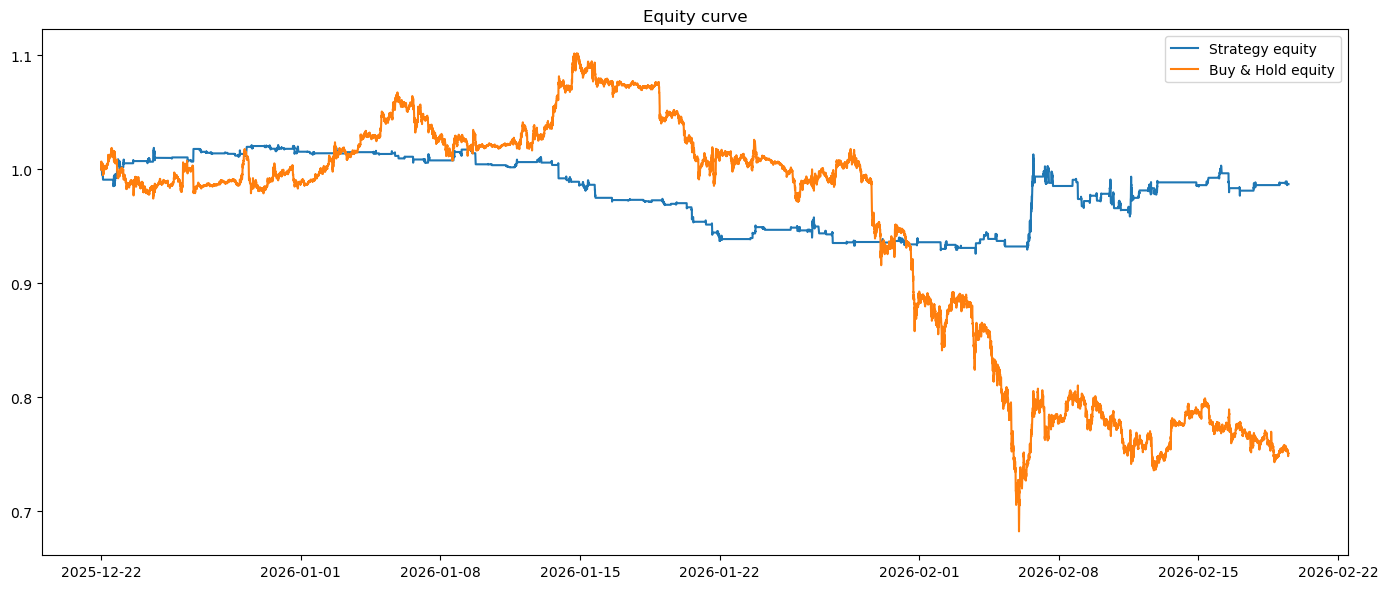

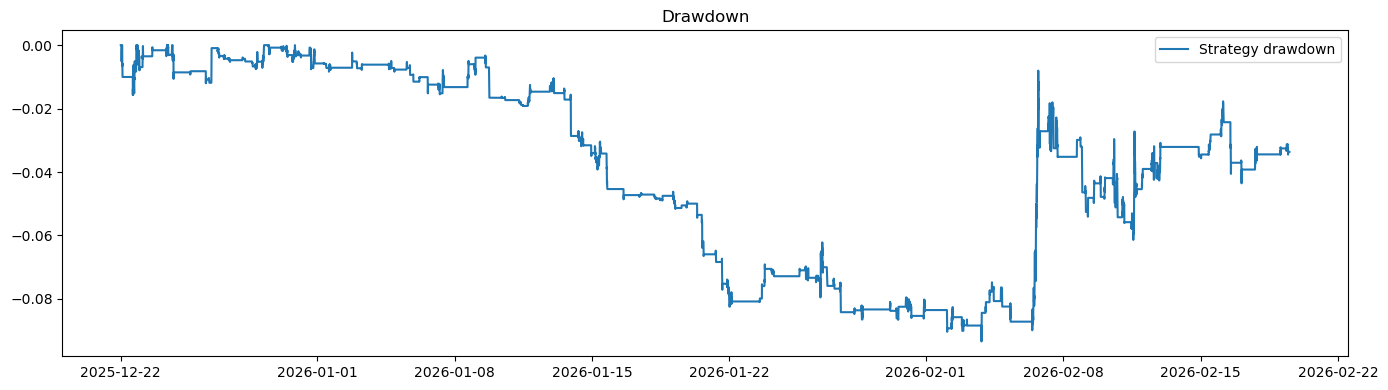

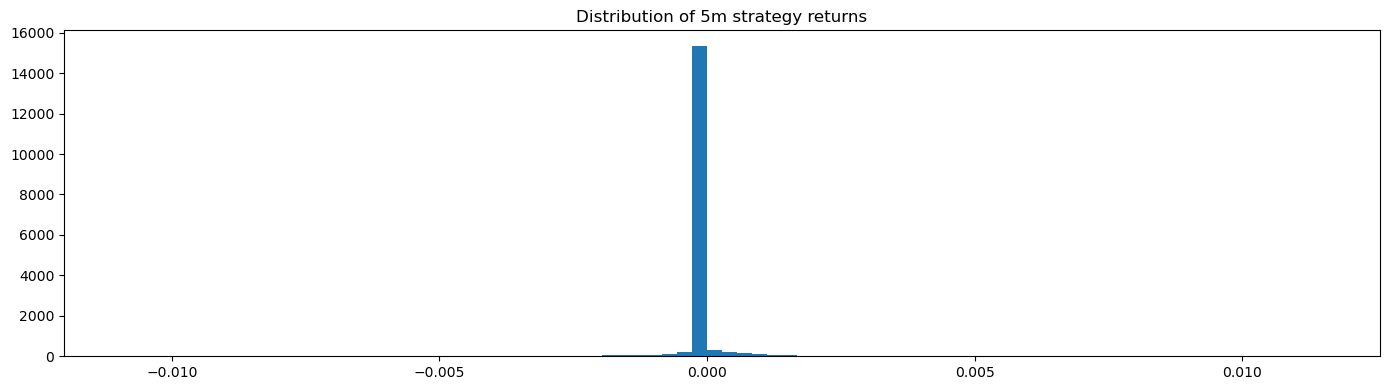

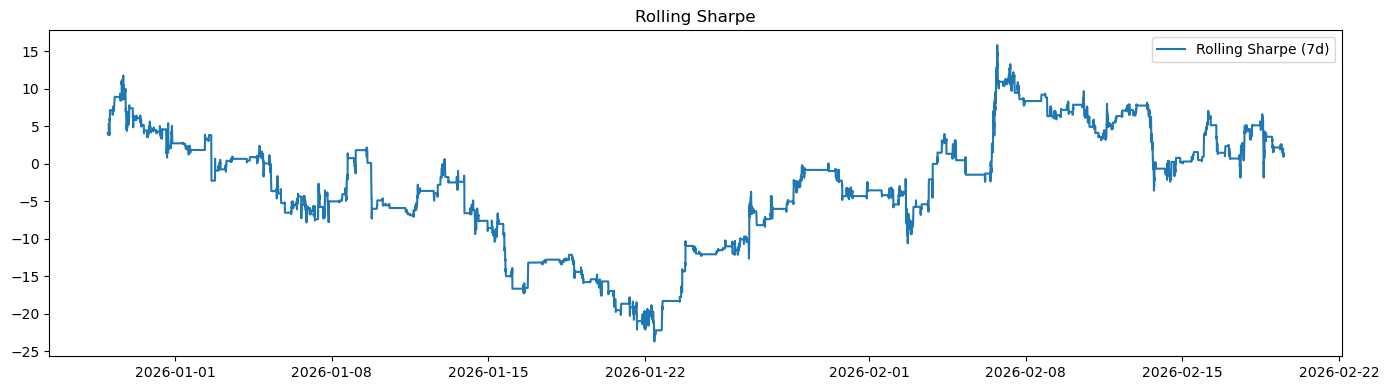

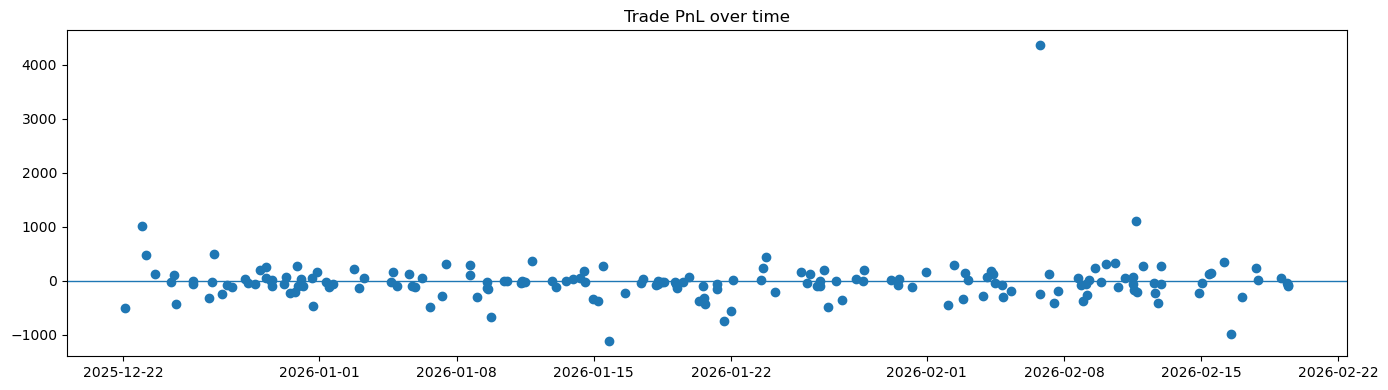

In [98]:
# ===================== CELL 9: PERFORMANCE / EQUITY / SHARPE / DRAWDOWN / PLOTS =====================
# Требует: trades_df, df_bt (как из run_backtest), и колонку df_bt["close"] с DatetimeIndex (5m)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- настройки ----------
START_EQUITY = 1.0              # стартовый капитал в "единицах"
BARS_PER_DAY = 24*60//5         # 288 для 5m
DAYS_PER_YEAR = 365
BARS_PER_YEAR = BARS_PER_DAY * DAYS_PER_YEAR
EPS = 1e-12

# ---------- safety ----------
if trades_df is None or len(trades_df) == 0:
    raise ValueError("trades_df пустой — нет сделок. Сначала запусти backtest.")

# ---------- 1) построим equity по сделкам (mark-to-market по close, без комиссий) ----------
# Позиции считаем бинарно: long=+1, short=-1. Внутри сделки держим позицию до exit_ts.
df_eq = df_bt[["close"]].copy()
df_eq["ret"] = df_eq["close"].pct_change().fillna(0.0)

# построим позицию во времени по сделкам
pos = pd.Series(0.0, index=df_eq.index)

for _, tr in trades_df.iterrows():
    if pd.isna(tr["entry_ts"]) or pd.isna(tr["exit_ts"]):
        continue
    side = 1.0 if tr["side"] == "long" else -1.0
    # позиция активна от entry_ts (включая) до exit_ts (включая) — максимально близко к логике баров
    mask = (pos.index >= tr["entry_ts"]) & (pos.index <= tr["exit_ts"])
    pos.loc[mask] = side

df_eq["pos"] = pos
df_eq["strat_ret"] = df_eq["pos"].shift(1).fillna(0.0) * df_eq["ret"]  # вход на следующем баре
df_eq["equity"] = START_EQUITY * (1.0 + df_eq["strat_ret"]).cumprod()

# buy&hold
df_eq["bh_equity"] = START_EQUITY * (1.0 + df_eq["ret"]).cumprod()

# ---------- 2) метрики ----------
def _sharpe(returns, periods_per_year):
    r = returns.dropna()
    if r.std(ddof=1) < EPS:
        return 0.0
    return (r.mean() / (r.std(ddof=1) + EPS)) * np.sqrt(periods_per_year)

def _sortino(returns, periods_per_year):
    r = returns.dropna()
    downside = r[r < 0]
    dd = downside.std(ddof=1)
    if dd < EPS:
        return 0.0
    return (r.mean() / (dd + EPS)) * np.sqrt(periods_per_year)

def _max_dd(equity):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return dd.min(), dd

# итоговая доходность
total_return = df_eq["equity"].iloc[-1] / df_eq["equity"].iloc[0] - 1.0
bh_return    = df_eq["bh_equity"].iloc[-1] / df_eq["bh_equity"].iloc[0] - 1.0

# CAGR (примерно, по календарю из индекса)
t_years = (df_eq.index.max() - df_eq.index.min()).total_seconds() / (365*24*3600)
cagr = (df_eq["equity"].iloc[-1] / df_eq["equity"].iloc[0]) ** (1.0 / max(t_years, EPS)) - 1.0
bh_cagr = (df_eq["bh_equity"].iloc[-1] / df_eq["bh_equity"].iloc[0]) ** (1.0 / max(t_years, EPS)) - 1.0

# Sharpe/Sortino (5m)
sharpe = _sharpe(df_eq["strat_ret"], BARS_PER_YEAR)
sortino = _sortino(df_eq["strat_ret"], BARS_PER_YEAR)

bh_sharpe = _sharpe(df_eq["ret"], BARS_PER_YEAR)

# max drawdown
mdd, dd_series = _max_dd(df_eq["equity"])
bh_mdd, bh_dd  = _max_dd(df_eq["bh_equity"])

# trade stats
tr = trades_df.copy()
tr["is_win"] = tr["pnl_$"] > 0
win_rate = tr["is_win"].mean()
avg_win  = tr.loc[tr["is_win"], "pnl_$"].mean() if tr["is_win"].any() else 0.0
avg_loss = tr.loc[~tr["is_win"], "pnl_$"].mean() if (~tr["is_win"]).any() else 0.0
profit_factor = (tr.loc[tr["pnl_$"] > 0, "pnl_$"].sum() / (abs(tr.loc[tr["pnl_$"] < 0, "pnl_$"].sum()) + EPS))

# expectancy per trade
expectancy = tr["pnl_$"].mean()

# ---------- 3) вывести сводку ----------
summary = pd.DataFrame([{
    "Сделок": len(tr),
    "Win rate": win_rate,
    "Profit factor": profit_factor,
    "Avg win ($)": avg_win,
    "Avg loss ($)": avg_loss,
    "Expectancy ($/trade)": expectancy,
    "Total return": total_return,
    "CAGR (approx)": cagr,
    "Sharpe (5m)": sharpe,
    "Sortino (5m)": sortino,
    "Max DD": mdd,
    "Buy&Hold return": bh_return,
    "Buy&Hold CAGR": bh_cagr,
    "Buy&Hold Sharpe": bh_sharpe,
    "Buy&Hold Max DD": bh_mdd,
}])

display(summary)

# ---------- 4) график equity (strategy vs buy&hold) ----------
plt.figure(figsize=(14,6))
plt.plot(df_eq.index, df_eq["equity"], label="Strategy equity")
plt.plot(df_eq.index, df_eq["bh_equity"], label="Buy & Hold equity")
plt.title("Equity curve")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 5) график drawdown ----------
plt.figure(figsize=(14,4))
plt.plot(df_eq.index, dd_series, label="Strategy drawdown")
plt.title("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 6) распределение доходностей (гистограмма 5m) ----------
plt.figure(figsize=(14,4))
plt.hist(df_eq["strat_ret"].values, bins=80)
plt.title("Distribution of 5m strategy returns")
plt.tight_layout()
plt.show()

# ---------- 7) rolling Sharpe (например 7 дней) ----------
window_days = 7
window = window_days * BARS_PER_DAY

roll_mean = df_eq["strat_ret"].rolling(window).mean()
roll_std  = df_eq["strat_ret"].rolling(window).std(ddof=1)
roll_sharpe = (roll_mean / (roll_std + EPS)) * np.sqrt(BARS_PER_YEAR)

plt.figure(figsize=(14,4))
plt.plot(df_eq.index, roll_sharpe, label=f"Rolling Sharpe ({window_days}d)")
plt.title("Rolling Sharpe")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 8) scatter: trade PnL по времени ----------
plt.figure(figsize=(14,4))
plt.scatter(tr["exit_ts"], tr["pnl_$"].values)
plt.axhline(0, linewidth=1)
plt.title("Trade PnL over time")
plt.tight_layout()
plt.show()


In [99]:
# ===================== TRADE TYPE STATS (CT vs TR vs FLIP) =====================

if trades_df.empty:
    raise ValueError("Нет сделок.")

# ---- 1) классификация по типу входа ----
def classify_trade(reason):
    if reason is None:
        return "UNKNOWN"
    r = reason.lower()
    if "ct" in r:
        return "CT"
    if "flip" in r:
        return "FLIP"
    if "tr" in r:
        return "TR"
    return "UNKNOWN"

# Если у тебя в trades_df нет явной информации о типе входа,
# лучше добавить её в backtest (я могу показать как).
# Пока используем reason как приближение:

tr = trades_df.copy()
tr["type"] = tr["reason"].apply(classify_trade)

# ---- 2) функция метрик ----
def trade_stats(df_sub):
    if len(df_sub) == 0:
        return {
            "Trades": 0,
            "Win rate": np.nan,
            "Avg win": np.nan,
            "Avg loss": np.nan,
            "Expectancy": np.nan,
            "Profit factor": np.nan
        }

    wins = df_sub[df_sub["pnl_$"] > 0]
    losses = df_sub[df_sub["pnl_$"] <= 0]

    win_rate = len(wins) / len(df_sub)
    avg_win = wins["pnl_$"].mean() if len(wins) > 0 else 0
    avg_loss = losses["pnl_$"].mean() if len(losses) > 0 else 0
    expectancy = df_sub["pnl_$"].mean()

    profit_factor = (
        wins["pnl_$"].sum() /
        (abs(losses["pnl_$"].sum()) + 1e-12)
    ) if len(losses) > 0 else np.inf

    return {
        "Trades": len(df_sub),
        "Win rate": win_rate,
        "Avg win": avg_win,
        "Avg loss": avg_loss,
        "Expectancy": expectancy,
        "Profit factor": profit_factor
    }

# ---- 3) считаем по группам ----
stats_ct   = trade_stats(tr[tr["type"] == "CT"])
stats_tr   = trade_stats(tr[tr["type"] == "TR"])
stats_flip = trade_stats(tr[tr["type"] == "FLIP"])

stats_df = pd.DataFrame({
    "CT (Counter-trend)": stats_ct,
    "TR (Trend)": stats_tr,
    "FLIP": stats_flip
}).T

display(stats_df)


,Trades,Win rate,Avg win,Avg loss,Expectancy,Profit factor
CT (Counter-trend),0.0,NaN,NaN,NaN,NaN,NaN
TR (Trend),176.0,0.403409,232.055489,-181.782847,-14.8367,0.863193
FLIP,0.0,NaN,NaN,NaN,NaN,NaN


In [100]:
def run_backtest_param(df: pd.DataFrame,
                       lenFast=20, lenSlow=20,
                       atrLen=20,
                       minDistATR=5.0,
                       tpQtyPct=70,
                       trailATR_CT=1.0,
                       trailATR_TR=5.0):
    """
    То же что твой run_backtest, но параметры передаются сюда.
    ВАЖНО: df должен содержать ohlc (open/high/low/close) и DatetimeIndex.
    """
    d = df.copy()

    # индикаторы
    d["atr"] = atr(d["high"], d["low"], d["close"], atrLen)
    d["trama_fast"] = trama_pine(d["close"], d["high"], d["low"], lenFast)

    d60 = resample_ohlc(d, "60min")
    d60["trama_slow_60"] = trama_pine(d60["close"], d60["high"], d60["low"], lenSlow)

    # как TV lookahead_off: только закрытые часы
    d["trama_slow"] = d60["trama_slow_60"].shift(1).reindex(d.index, method="ffill")

    # сигналы
    prev_close = d["close"].shift(1)
    prev_fast  = d["trama_fast"].shift(1)
    d["crossUp"]   = (prev_close <= prev_fast) & (d["close"] > d["trama_fast"])
    d["crossDown"] = (prev_close >= prev_fast) & (d["close"] < d["trama_fast"])

    d["distLong"]  = d["trama_slow"] - d["close"]
    d["distShort"] = d["close"] - d["trama_slow"]
    d["validDistLong"]  = d["distLong"]  > d["atr"] * minDistATR
    d["validDistShort"] = d["distShort"] > d["atr"] * minDistATR

    # ---- тут используем твою торговую логику из run_backtest,
    # но вместо глобальных параметров берём tpQtyPct, trailATR_CT, trailATR_TR
    # Я просто вызываю ниже твою функцию run_backtest, если ты её уже поправил под параметры,
    # иначе вставь внутрь твою логику из run_backtest (там 2 места: tpQtyPct и trail multipliers).
    #
    # ВАЖНО: чтобы это работало без переписывания, проще:
    # 1) скопировать тело твоего run_backtest сюда и заменить tpQtyPct/trailATR_CT/trailATR_TR.
    #
    trades_df, d_bt = run_backtest_with_precomputed_indicators(
        d,
        tpQtyPct=tpQtyPct,
        trailATR_CT=trailATR_CT,
        trailATR_TR=trailATR_TR
    )
    return trades_df, d_bt


In [101]:
def run_backtest_with_precomputed_indicators(df: pd.DataFrame,
                                             tpQtyPct=70,
                                             trailATR_CT=1.0,
                                             trailATR_TR=5.0):
    """
    Твоя торговая логика, но df уже содержит:
    atr, trama_fast, trama_slow, crossUp/crossDown, validDistLong/validDistShort
    """
    from dataclasses import dataclass

    @dataclass
    class Trade:
        entry_ts: pd.Timestamp
        side: str
        entry_px: float
        exit_ts: pd.Timestamp | None = None
        exit_px: float | None = None
        reason: str | None = None
        mode: int | None = None  # сохраним тип входа: 1/-1 CT, 2/-2 TR, 3/-3 FLIP

    pos = 0
    posMode = 0
    qty = 1.0
    qty_open = 0.0
    ctNear = False
    ctNear_i = None
    trArmL, trCntL = False, 0
    trArmS, trCntS = False, 0
    trailL = np.nan
    trailS = np.nan

    trades = []
    cur_trade = None

    def open_pos(i, side, mode):
        nonlocal pos, posMode, qty_open, ctNear, ctNear_i, trailL, trailS, cur_trade
        pos = 1 if side == "long" else -1
        posMode = mode
        qty_open = qty
        ctNear = False
        ctNear_i = None
        trailL = np.nan
        trailS = np.nan
        cur_trade = Trade(entry_ts=df.index[i], side=side, entry_px=float(df["close"].iloc[i]), mode=mode)
        trades.append(cur_trade)

    def close_pos(i, px, reason):
        nonlocal pos, posMode, qty_open, ctNear, ctNear_i, trailL, trailS, cur_trade
        if pos == 0:
            return
        cur_trade.exit_ts = df.index[i]
        cur_trade.exit_px = float(px)
        cur_trade.reason = reason
        pos = 0
        posMode = 0
        qty_open = 0.0
        ctNear = False
        ctNear_i = None
        trailL = np.nan
        trailS = np.nan

    for i in range(2, len(df)):
        row = df.iloc[i]
        if np.isnan(row["trama_slow"]) or np.isnan(row["trama_fast"]) or np.isnan(row["atr"]):
            continue

        close = float(row["close"])
        high  = float(row["high"])
        low   = float(row["low"])
        slow  = float(row["trama_slow"])
        fast  = float(row["trama_fast"])
        atrv  = float(row["atr"])

        # === entries (flat) ===
        if pos == 0:
            # TR long: prev close above slow AND retest (low<=slow) then 3 closes above slow
            if (df["close"].iloc[i-1] > df["trama_slow"].iloc[i-1]) and (low <= slow):
                trArmL, trCntL = True, 0
            if trArmL:
                if close > slow:
                    trCntL += 1
                    if trCntL >= 3:
                        open_pos(i, "long", 2)
                        trArmL, trCntL = False, 0
                else:
                    trArmL, trCntL = False, 0

            # TR short: prev close below slow AND retest (high>=slow) then 3 closes below slow
            if (df["close"].iloc[i-1] < df["trama_slow"].iloc[i-1]) and (high >= slow):
                trArmS, trCntS = True, 0
            if trArmS:
                if close < slow:
                    trCntS += 1
                    if trCntS >= 3:
                        open_pos(i, "short", -2)
                        trArmS, trCntS = False, 0
                else:
                    trArmS, trCntS = False, 0

            # CT entries (если всё ещё flat)
            if pos == 0:
                ctLong  = (close < slow) and bool(row["crossUp"]) and bool(row["validDistLong"])
                ctShort = (close > slow) and bool(row["crossDown"]) and bool(row["validDistShort"])
                if ctLong:
                    open_pos(i, "long", 1)
                elif ctShort:
                    open_pos(i, "short", -1)
            continue

        # === management ===
        trail_mult = trailATR_TR if posMode in (2, -2, 3, -3) else trailATR_CT

        # CT partial TP at slow + mark ctNear on touch
        if posMode == 1:  # CT long
            if (not ctNear) and (high >= slow):
                ctNear, ctNear_i = True, i
            if high >= slow and qty_open > 0:
                qty_close = qty * (tpQtyPct / 100.0)
                if qty_open > qty - qty_close + 1e-9:
                    qty_open -= qty_close

        if posMode == -1:  # CT short
            if (not ctNear) and (low <= slow):
                ctNear, ctNear_i = True, i
            if low <= slow and qty_open > 0:
                qty_close = qty * (tpQtyPct / 100.0)
                if qty_open > qty - qty_close + 1e-9:
                    qty_open -= qty_close

        # CT 3-bar flip
        if posMode == 1 and ctNear and (i - ctNear_i >= 2):
            three_below = (df["close"].iloc[i] < df["trama_slow"].iloc[i]) and \
                          (df["close"].iloc[i-1] < df["trama_slow"].iloc[i-1]) and \
                          (df["close"].iloc[i-2] < df["trama_slow"].iloc[i-2])
            if three_below:
                close_pos(i, close, "CT 3 closes below slow -> flip short")
                if fast < slow:
                    open_pos(i, "short", 3)
                continue

        if posMode == -1 and ctNear and (i - ctNear_i >= 2):
            three_above = (df["close"].iloc[i] > df["trama_slow"].iloc[i]) and \
                          (df["close"].iloc[i-1] > df["trama_slow"].iloc[i-1]) and \
                          (df["close"].iloc[i-2] > df["trama_slow"].iloc[i-2])
            if three_above:
                close_pos(i, close, "CT 3 closes above slow -> flip long")
                if fast > slow:
                    open_pos(i, "long", -3)
                continue

        # trailing levels
        if pos > 0:
            newL = close - atrv * trail_mult
            trailL = newL if np.isnan(trailL) else max(trailL, newL)
        else:
            newS = close + atrv * trail_mult
            trailS = newS if np.isnan(trailS) else min(trailS, newS)

        # intrabar stop hits
        if pos > 0 and not np.isnan(trailL) and (low <= trailL):
            was_ct = (posMode == 1)
            was_ct_near = ctNear
            close_pos(i, trailL, "Trailing stop hit (long)")
            if was_ct and was_ct_near and fast < slow:
                open_pos(i, "short", 3)
            continue

        if pos < 0 and not np.isnan(trailS) and (high >= trailS):
            was_ct = (posMode == -1)
            was_ct_near = ctNear
            close_pos(i, trailS, "Trailing stop hit (short)")
            if was_ct and was_ct_near and fast > slow:
                open_pos(i, "long", -3)
            continue

        if qty_open <= 1e-9:
            close_pos(i, close, "Position size reached 0 after partial")
            continue

    if pos != 0:
        close_pos(len(df)-1, float(df["close"].iloc[-1]), "End of data")

    out = []
    for t in trades:
        if t.exit_ts is None:
            continue
        pnl = (t.exit_px - t.entry_px) if t.side == "long" else (t.entry_px - t.exit_px)
        out.append({
            "entry_ts": t.entry_ts, "exit_ts": t.exit_ts,
            "side": t.side, "entry_px": t.entry_px, "exit_px": t.exit_px,
            "pnl_$": pnl,
            "reason": t.reason,
            "mode": t.mode
        })
    trades_df = pd.DataFrame(out)
    return trades_df, df


In [102]:
# ===================== TRAMA (Pine-like) =====================

def trama_pine(src_close, high, low, length=20):
    highest = high.rolling(length, min_periods=1).max()
    lowest  = low.rolling(length,  min_periods=1).min()

    hh = np.maximum(np.sign(highest.diff()), 0.0)
    ll = np.maximum(np.sign(lowest.diff()) * -1.0, 0.0)

    cond = ((hh != 0) | (ll != 0)).astype(float)

    # Pine ta.sma behaviour: первые length-1 баров -> NaN
    sma_cond = cond.rolling(length, min_periods=length).mean()
    tc = sma_cond ** 2

    ama = pd.Series(index=src_close.index, dtype=float)
    ama.iloc[0] = float(src_close.iloc[0])

    for i in range(1, len(src_close)):
        prev = ama.iloc[i-1]
        a = tc.iloc[i]

        if pd.isna(a) or pd.isna(prev):
            ama.iloc[i] = float(src_close.iloc[i])
        else:
            ama.iloc[i] = prev + float(a) * (float(src_close.iloc[i]) - prev)

    return ama


In [103]:
import numpy as np
import pandas as pd

N_RUNS = 1000
SEED = 42
rng = np.random.default_rng(SEED)

# Диапазоны параметров (можешь менять)
SPACE = {
    "lenFast":     (10, 60),       # int
    "lenSlow":     (15, 60),       # int
    "atrLen":      (18, 22),        # int
    "minDistATR":  (3.0, 5.5),     # float
    "tpQtyPct":    (50, 90),       # int
    "trailATR_CT": (1.0, 3.0),     # float
    "trailATR_TR": (1.5, 4.5),     # float (и должен быть >= CT обычно)
}

def sample_params():
    lenFast = int(rng.integers(SPACE["lenFast"][0], SPACE["lenFast"][1]+1))
    lenSlow = int(rng.integers(SPACE["lenSlow"][0], SPACE["lenSlow"][1]+1))
    atrLen  = int(rng.integers(SPACE["atrLen"][0],  SPACE["atrLen"][1]+1))
    minDist = float(rng.uniform(*SPACE["minDistATR"]))
    tpPct   = int(rng.integers(SPACE["tpQtyPct"][0], SPACE["tpQtyPct"][1]+1))
    trailCT = float(rng.uniform(*SPACE["trailATR_CT"]))
    trailTR = float(rng.uniform(*SPACE["trailATR_TR"]))

    # логичное ограничение: трендовый трейл шире/выше
    if trailTR < trailCT:
        trailTR = trailCT + 0.3

    return dict(
        lenFast=lenFast, lenSlow=lenSlow, atrLen=atrLen,
        minDistATR=minDist, tpQtyPct=tpPct,
        trailATR_CT=trailCT, trailATR_TR=trailTR
    )

# --- helpers: equity + sharpe ---
BARS_PER_DAY = 288
BARS_PER_YEAR = BARS_PER_DAY * 365
EPS = 1e-12

def equity_from_trades(df_price: pd.DataFrame, trades: pd.DataFrame):
    eq = df_price[["close"]].copy()
    eq["ret"] = eq["close"].pct_change().fillna(0.0)
    pos = pd.Series(0.0, index=eq.index)

    for _, tr in trades.iterrows():
        side = 1.0 if tr["side"] == "long" else -1.0
        m = (pos.index >= tr["entry_ts"]) & (pos.index <= tr["exit_ts"])
        pos.loc[m] = side

    eq["pos"] = pos
    eq["strat_ret"] = eq["pos"].shift(1).fillna(0.0) * eq["ret"]
    eq["equity"] = (1.0 + eq["strat_ret"]).cumprod()
    return eq

def sharpe_ann(returns):
    r = returns.dropna()
    if r.std(ddof=1) < EPS:
        return 0.0
    return (r.mean() / (r.std(ddof=1) + EPS)) * np.sqrt(BARS_PER_YEAR)

def rolling_sharpe(returns, window_days=7):
    w = window_days * BARS_PER_DAY
    mu = returns.rolling(w).mean()
    sd = returns.rolling(w).std(ddof=1)
    return (mu / (sd + EPS)) * np.sqrt(BARS_PER_YEAR)

# --- main loop ---
results = []
equity_lines = []
sharpe_lines = []

for k in range(N_RUNS):
    p = sample_params()

    # 1) пересчёт индикаторов под параметры (быстро — только столбцы, цены те же)
    d = df[["open","high","low","close","volume"]].copy()
    d["atr"] = atr(d["high"], d["low"], d["close"], p["atrLen"])
    d["trama_fast"] = trama_pine(d["close"], d["high"], d["low"], p["lenFast"])

    d60 = resample_ohlc(d, "60min")
    d60["trama_slow_60"] = trama_pine(d60["close"], d60["high"], d60["low"], p["lenSlow"])
    d["trama_slow"] = d60["trama_slow_60"].shift(1).reindex(d.index, method="ffill")

    prev_close = d["close"].shift(1)
    prev_fast  = d["trama_fast"].shift(1)
    d["crossUp"]   = (prev_close <= prev_fast) & (d["close"] > d["trama_fast"])
    d["crossDown"] = (prev_close >= prev_fast) & (d["close"] < d["trama_fast"])

    d["distLong"]  = d["trama_slow"] - d["close"]
    d["distShort"] = d["close"] - d["trama_slow"]
    d["validDistLong"]  = d["distLong"]  > d["atr"] * p["minDistATR"]
    d["validDistShort"] = d["distShort"] > d["atr"] * p["minDistATR"]

    # 2) сделки
    trades_df_k, _ = run_backtest_with_precomputed_indicators(
        d,
        tpQtyPct=p["tpQtyPct"],
        trailATR_CT=p["trailATR_CT"],
        trailATR_TR=p["trailATR_TR"]
    )

    if trades_df_k.empty:
        results.append({**p, "run": k, "trades": 0, "profit": 0.0, "sharpe": 0.0})
        continue

    # 3) equity / metrics
    eq = equity_from_trades(d, trades_df_k)
    profit = float(eq["equity"].iloc[-1] - 1.0)
    sh = float(sharpe_ann(eq["strat_ret"]))
    ntr = int(len(trades_df_k))

    # сохраняем линии для спагетти
    equity_lines.append(eq["equity"].rename(k))
    sharpe_lines.append(rolling_sharpe(eq["strat_ret"]).rename(k))

    results.append({**p, "run": k, "trades": ntr, "profit": profit, "sharpe": sh})

res_mc = pd.DataFrame(results)
res_mc = res_mc.sort_values(["profit","sharpe"], ascending=False).reset_index(drop=True)

display(res_mc.head(20))
print("OK runs:", len(res_mc), "| with trades:", (res_mc["trades"]>0).sum())


,lenFast,lenSlow,atrLen,minDistATR,tpQtyPct,trailATR_CT,trailATR_TR,run,trades,profit,sharpe
0,44,43,21,3.219125,64,1.236012,4.385693,19,407,0.173444,4.136996
1,48,43,22,3.050653,68,1.499096,1.855456,574,402,0.157335,4.197184
2,42,43,19,3.827302,84,1.390286,2.295064,925,425,0.143131,3.717357
3,16,42,19,4.106640,79,1.312583,1.812454,441,733,0.131164,2.913539
4,15,19,18,5.164218,77,1.282863,2.598317,907,604,0.130935,3.059445
5,12,34,20,4.256698,60,1.303603,2.555790,434,817,0.124355,2.542337
6,15,19,21,4.154693,79,1.322544,3.003134,17,659,0.123301,2.723058
7,15,56,21,3.776851,59,1.321246,2.421603,996,779,0.122168,2.591474
8,52,41,18,5.066906,65,1.277161,2.785178,466,344,0.116528,3.369776
9,42,45,20,3.689088,51,1.188460,2.072181,656,443,0.114193,3.295738


OK runs: 1000 | with trades: 1000


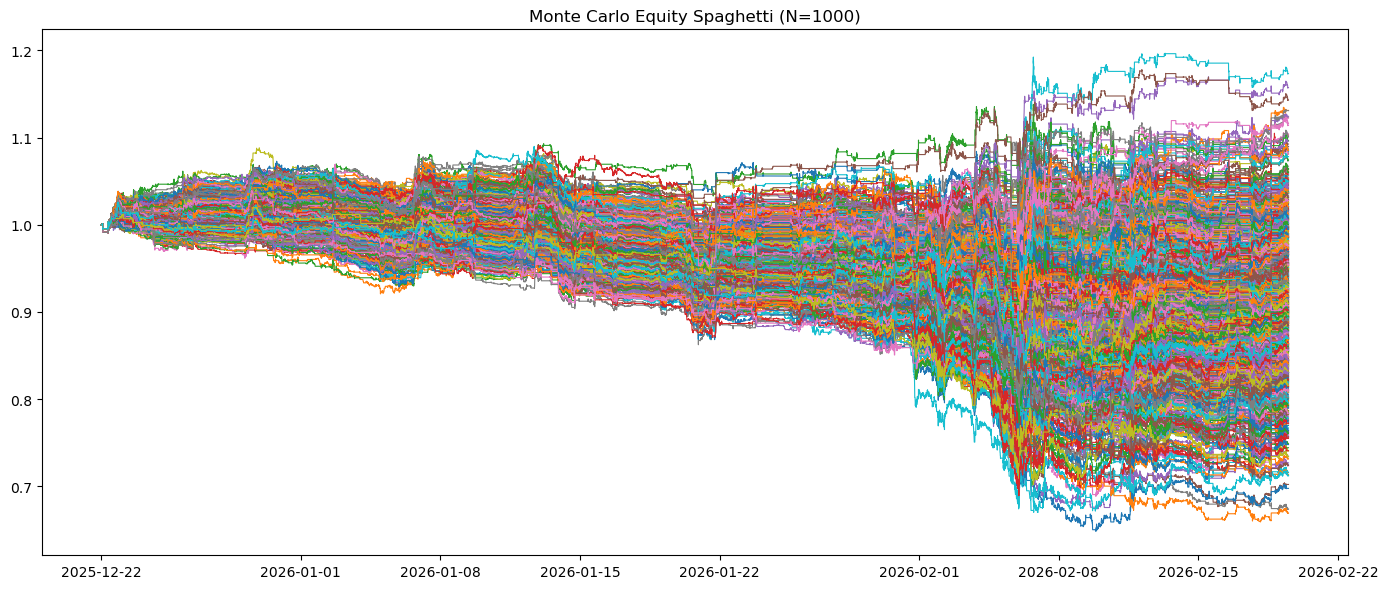

In [119]:
# ===================== SPAGHETTI EQUITY =====================
if len(equity_lines) == 0:
    raise ValueError("Нет ни одной equity-линии (возможно, нет сделок).")

eq_mat = pd.concat(equity_lines, axis=1)

plt.figure(figsize=(14,6))
plt.plot(eq_mat.index, eq_mat.values, linewidth=0.8)
plt.title(f"Monte Carlo Equity Spaghetti (N={eq_mat.shape[1]})")
plt.tight_layout()
plt.show()


In [128]:
# ===================== GET PARAMS BY RANK =====================
# rank=1 -> лучший, rank=2 -> второй, и т.д.
rank = 1  # <-- меняй

i = rank - 1
if i < 0 or i >= len(res_mc):
    raise ValueError("Неверный rank.")

row = res_mc.iloc[i].to_dict()

print(f"RANK #{rank}")
for k in ["profit","sharpe","trades","run"]:
    print(f"{k}: {row[k]}")
print("PARAMS:")
for k in ["lenFast","lenSlow","atrLen","minDistATR","tpQtyPct","trailATR_CT","trailATR_TR"]:
    print(f"  {k}: {row[k]}")


RANK #1
profit: 0.17344405398523488
sharpe: 4.1369964217615065
trades: 407.0
run: 19.0
PARAMS:
  lenFast: 44.0
  lenSlow: 43.0
  atrLen: 21.0
  minDistATR: 3.2191247982902524
  tpQtyPct: 64.0
  trailATR_CT: 1.2360118042410306
  trailATR_TR: 4.385692993648544


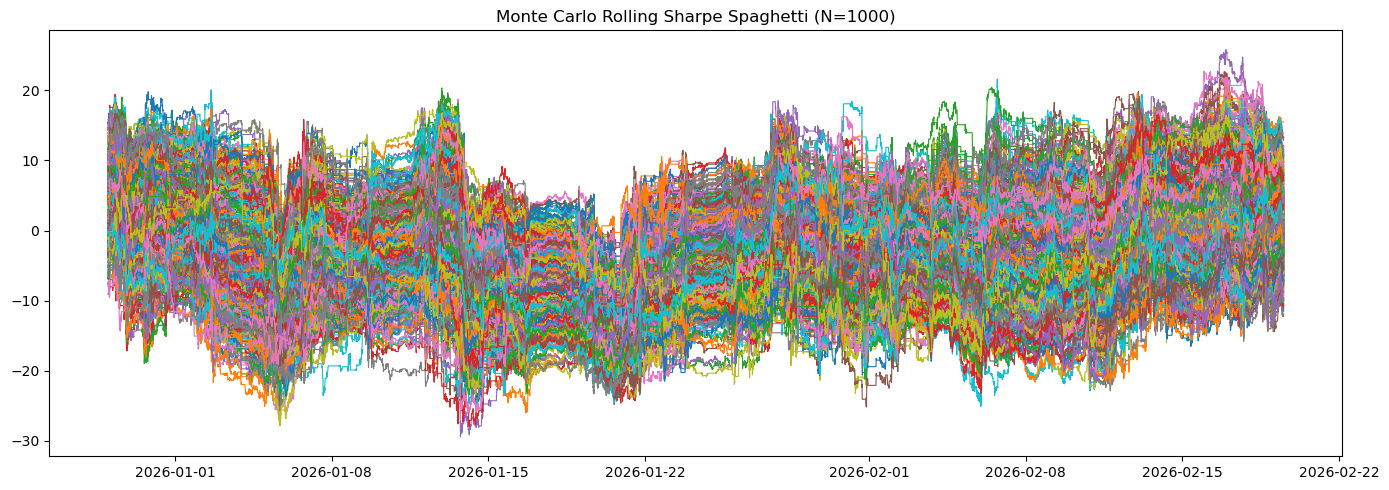

In [121]:
# ===================== SPAGHETTI ROLLING SHARPE =====================
if len(sharpe_lines) == 0:
    raise ValueError("Нет линий rolling Sharpe (возможно, нет сделок).")

sh_mat = pd.concat(sharpe_lines, axis=1)

plt.figure(figsize=(14,5))
plt.plot(sh_mat.index, sh_mat.values, linewidth=0.8)
plt.title(f"Monte Carlo Rolling Sharpe Spaghetti (N={sh_mat.shape[1]})")
plt.tight_layout()
plt.show()


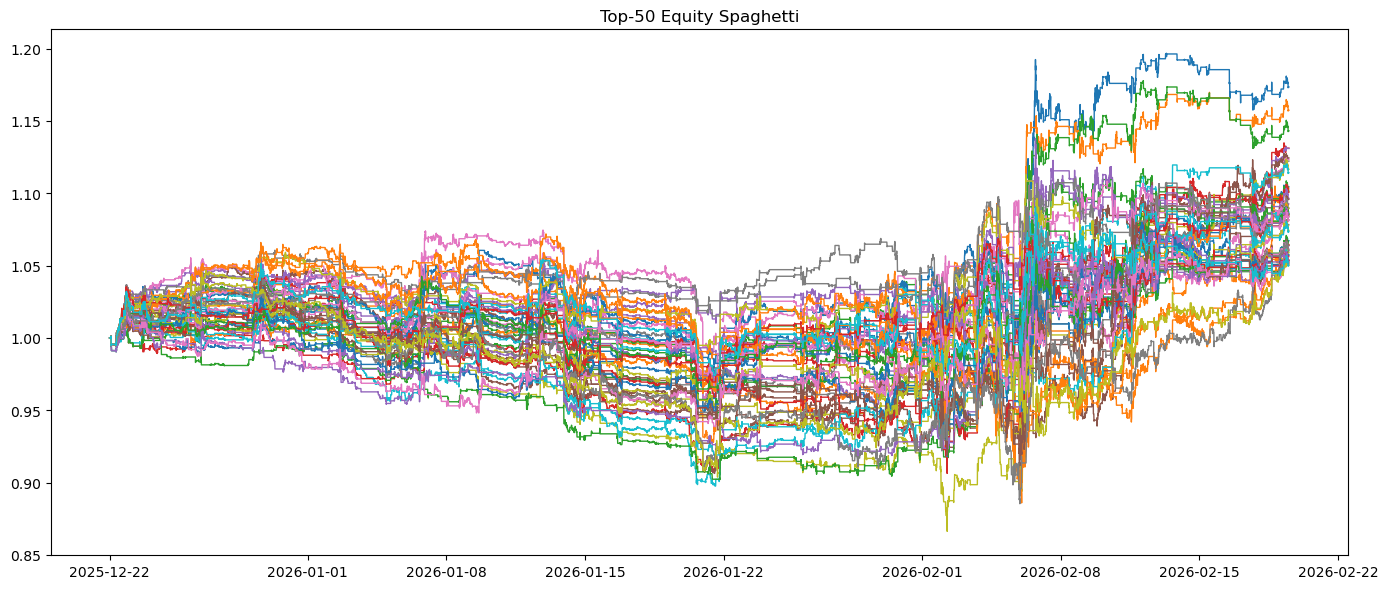

In [122]:
TOPK = 50
top_runs = res_mc.head(TOPK)["run"].astype(int).tolist()

eq_mat_top = eq_mat[top_runs] if set(top_runs).issubset(eq_mat.columns) else eq_mat
plt.figure(figsize=(14,6))
plt.plot(eq_mat_top.index, eq_mat_top.values, linewidth=1.0)
plt.title(f"Top-{TOPK} Equity Spaghetti")
plt.tight_layout()
plt.show()


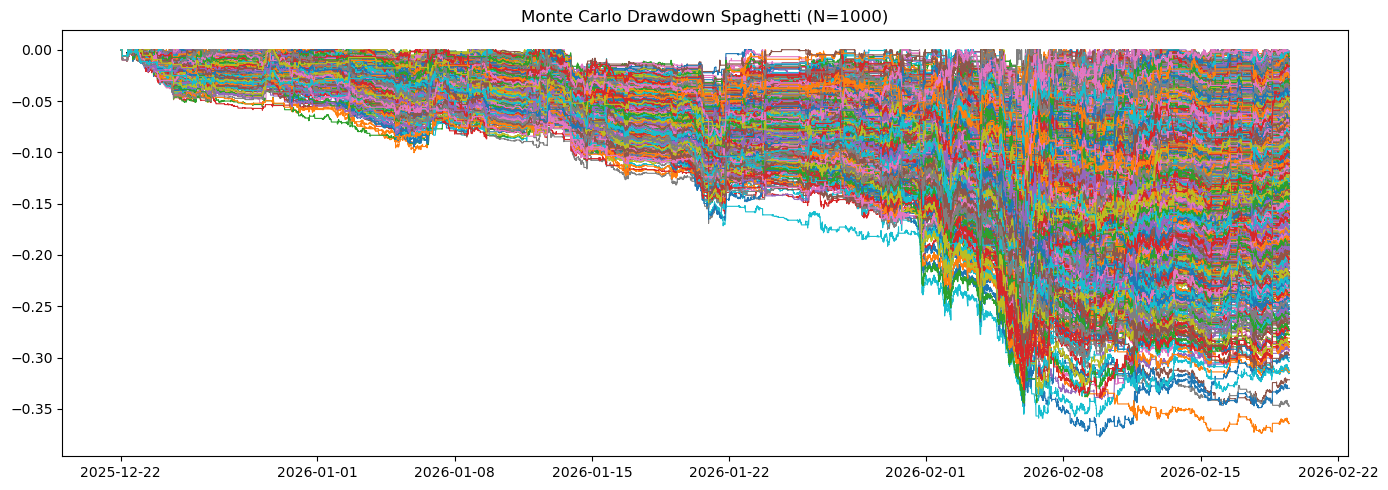

In [123]:
# ===================== SPAGHETTI DRAWDOWN (PATHS) =====================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Собираем матрицу equity, если ещё не собрана
if "eq_mat" not in globals():
    if "equity_lines" not in globals() or len(equity_lines) == 0:
        raise ValueError("Нет equity_lines/eq_mat. Сначала запусти Monte Carlo и собери equity_lines.")
    eq_mat = pd.concat(equity_lines, axis=1)

# 2) Drawdown path: equity / running_max - 1
peak = eq_mat.cummax()
dd_mat = (eq_mat / peak) - 1.0  # отрицательные значения

plt.figure(figsize=(14,5))
plt.plot(dd_mat.index, dd_mat.values, linewidth=0.8)
plt.title(f"Monte Carlo Drawdown Spaghetti (N={dd_mat.shape[1]})")
plt.tight_layout()
plt.show()


,run,max_drawdown
580,580,-0.377300
751,751,-0.373803
599,599,-0.359090
377,377,-0.348214
660,660,-0.347315
319,319,-0.347025
205,205,-0.346132
862,862,-0.344324
899,899,-0.342027
374,374,-0.340785


,run,max_drawdown
845,845,-0.059735
757,757,-0.058689
837,837,-0.058283
682,682,-0.058099
117,117,-0.056363
210,210,-0.055856
294,294,-0.053154
123,123,-0.052309
476,476,-0.051744
74,74,-0.047921


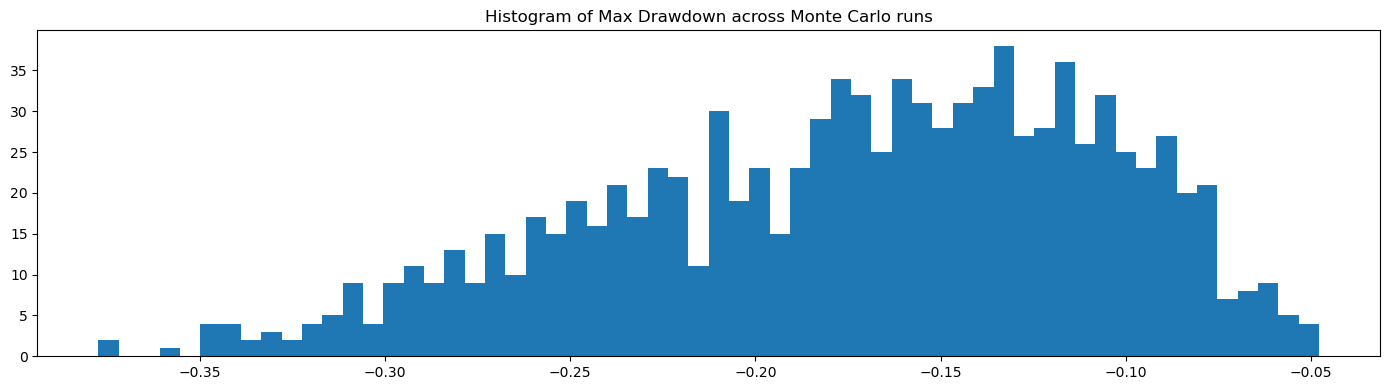

In [124]:
# ===================== MAX DRAWDOWN PER RUN + HIST =====================

# dd_mat уже посчитан выше. Если нет — считаем.
if "dd_mat" not in globals():
    peak = eq_mat.cummax()
    dd_mat = (eq_mat / peak) - 1.0

mdd_per_run = dd_mat.min(axis=0)  # самое отрицательное значение для каждого прогона
mdd_df = pd.DataFrame({
    "run": mdd_per_run.index.astype(int),
    "max_drawdown": mdd_per_run.values
}).sort_values("max_drawdown")  # хуже -> лучше

display(mdd_df.head(10))   # 10 худших по просадке
display(mdd_df.tail(10))   # 10 лучших (наименее глубоких)

plt.figure(figsize=(14,4))
plt.hist(mdd_df["max_drawdown"].values, bins=60)
plt.title("Histogram of Max Drawdown across Monte Carlo runs")
plt.tight_layout()
plt.show()


In [125]:
# ===================== BEST (MIN) MAX DRAWDOWN PARAMS =====================

# Убедимся что dd_mat существует
if "dd_mat" not in globals():
    if "eq_mat" not in globals():
        raise ValueError("Нет eq_mat. Сначала запусти Monte Carlo.")
    peak = eq_mat.cummax()
    dd_mat = (eq_mat / peak) - 1.0

# max drawdown по каждому прогону
mdd_per_run = dd_mat.min(axis=0)  # самое отрицательное значение

# Самый маленький по глубине (т.е. ближе всего к 0)
best_run = mdd_per_run.idxmax()  # максимальное значение (например -0.12 лучше чем -0.45)

best_mdd = mdd_per_run.loc[best_run]

# параметры этого прогона из res_mc
row = res_mc[res_mc["run"] == best_run].iloc[0]

print("===== BEST MIN DRAWDOWN RUN =====")
print("Run ID:", int(best_run))
print("Max Drawdown:", float(best_mdd))
print("Profit:", float(row["profit"]))
print("Sharpe:", float(row["sharpe"]))
print("Trades:", int(row["trades"]))
print("\nPARAMETERS:")
for k in ["lenFast","lenSlow","atrLen","minDistATR","tpQtyPct","trailATR_CT","trailATR_TR"]:
    print(f"{k}: {row[k]}")


===== BEST MIN DRAWDOWN RUN =====
Run ID: 74
Max Drawdown: -0.04792052919815226
Profit: 0.08361221881439596
Sharpe: 2.2817191414231606
Trades: 368

PARAMETERS:
lenFast: 51.0
lenSlow: 50.0
atrLen: 21.0
minDistATR: 3.910480044430135
tpQtyPct: 61.0
trailATR_CT: 1.6288799604085258
trailATR_TR: 1.972834945874999


In [126]:
# ===================== WORST MAX DRAWDOWN =====================

# если dd_mat нет — пересчитать
if "dd_mat" not in globals():
    peak = eq_mat.cummax()
    dd_mat = (eq_mat / peak) - 1.0

mdd_per_run = dd_mat.min(axis=0)

# худший = самая глубокая просадка (самое отрицательное число)
worst_run_dd = mdd_per_run.idxmin()
worst_mdd = mdd_per_run.loc[worst_run_dd]

row = res_mc[res_mc["run"] == worst_run_dd].iloc[0]

print("===== WORST MAX DRAWDOWN RUN =====")
print("Run ID:", int(worst_run_dd))
print("Max Drawdown:", float(worst_mdd))
print("Profit:", float(row["profit"]))
print("Sharpe:", float(row["sharpe"]))
print("Trades:", int(row["trades"]))
print("\nPARAMETERS:")
for k in ["lenFast","lenSlow","atrLen","minDistATR","tpQtyPct","trailATR_CT","trailATR_TR"]:
    print(f"{k}: {row[k]}")


===== WORST MAX DRAWDOWN RUN =====
Run ID: 580
Max Drawdown: -0.37730028444753416
Profit: -0.30235641225025733
Sharpe: -5.725723787324217
Trades: 504

PARAMETERS:
lenFast: 16.0
lenSlow: 32.0
atrLen: 20.0
minDistATR: 3.3730693211006413
tpQtyPct: 88.0
trailATR_CT: 2.9941380221524874
trailATR_TR: 3.294138022152487


In [127]:
# ===================== BEST & WORST SHARPE =====================

# Лучший Sharpe
best_run_sh = res_mc.loc[res_mc["sharpe"].idxmax()]
# Худший Sharpe
worst_run_sh = res_mc.loc[res_mc["sharpe"].idxmin()]

print("===== BEST SHARPE =====")
print("Run ID:", int(best_run_sh["run"]))
print("Sharpe:", float(best_run_sh["sharpe"]))
print("Profit:", float(best_run_sh["profit"]))
print("Max DD:", float(dd_mat.min(axis=0).loc[best_run_sh["run"]]))
print("Trades:", int(best_run_sh["trades"]))
print("PARAMETERS:")
for k in ["lenFast","lenSlow","atrLen","minDistATR","tpQtyPct","trailATR_CT","trailATR_TR"]:
    print(f"{k}: {best_run_sh[k]}")

print("\n\n===== WORST SHARPE =====")
print("Run ID:", int(worst_run_sh["run"]))
print("Sharpe:", float(worst_run_sh["sharpe"]))
print("Profit:", float(worst_run_sh["profit"]))
print("Max DD:", float(dd_mat.min(axis=0).loc[worst_run_sh["run"]]))
print("Trades:", int(worst_run_sh["trades"]))
print("PARAMETERS:")
for k in ["lenFast","lenSlow","atrLen","minDistATR","tpQtyPct","trailATR_CT","trailATR_TR"]:
    print(f"{k}: {worst_run_sh[k]}")


===== BEST SHARPE =====
Run ID: 574
Sharpe: 4.197184264838074
Profit: 0.15733456529291456
Max DD: -0.07500091235161432
Trades: 402
PARAMETERS:
lenFast: 48.0
lenSlow: 43.0
atrLen: 22.0
minDistATR: 3.050652820510348
tpQtyPct: 68.0
trailATR_CT: 1.4990963518774407
trailATR_TR: 1.8554557570644046


===== WORST SHARPE =====
Run ID: 377
Sharpe: -8.179729081727466
Profit: -0.3261840548409388
Max DD: -0.34821364102460306
Trades: 407
PARAMETERS:
lenFast: 31.0
lenSlow: 30.0
atrLen: 20.0
minDistATR: 3.471780525072298
tpQtyPct: 55.0
trailATR_CT: 2.7010417578427153
trailATR_TR: 2.8388470157413246
